In [1]:
#import libaries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


In [2]:
sample_path = "C:/Users/hp/Downloads/collected_data.csv"

In [4]:
df = pd.read_csv(sample_path)

In [5]:
print("\nFirst 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,Unnamed: 0,is_cluster,molecule_type,ncbi_family,ncbi_genus,ncbi_species,sequence_gc_content,sequence_length,sequence_title,sequence_completeness,submitter_country
0,0,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,14449,"MAG TPA_asm: Podoviridae sp. isolate ctU6X1, p...",partial,USA
1,1,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,12855,"MAG TPA_asm: Siphoviridae sp. isolate ctoxf14,...",partial,USA
2,2,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,39803,"MAG TPA_asm: Myoviridae sp. isolate ctaaE5, pa...",partial,USA
3,3,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,64002,"MAG TPA_asm: Podoviridae sp. isolate ctxdM6, p...",partial,USA
4,4,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,116470,"MAG TPA_asm: Siphoviridae sp. isolate ct3B41, ...",partial,USA


In [6]:
print("\nLast 5 rows of the dataset:")
df.tail()


Last 5 rows of the dataset:


,Unnamed: 0,is_cluster,molecule_type,ncbi_family,ncbi_genus,ncbi_species,sequence_gc_content,sequence_length,sequence_title,sequence_completeness,submitter_country
13049915,13049915,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.958950,29890,Severe acute respiratory syndrome coronavirus ...,partial,United Kingdom
13049916,13049916,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.956867,29890,Severe acute respiratory syndrome coronavirus ...,partial,United Kingdom
13049917,13049917,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.967808,29890,Severe acute respiratory syndrome coronavirus ...,partial,United Kingdom
13049918,13049918,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.945724,29814,Severe acute respiratory syndrome coronavirus ...,partial,Germany
13049919,13049919,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.992573,29896,Severe acute respiratory syndrome coronavirus ...,complete,United Kingdom


In [7]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (13049920, 11)


In [8]:
#missing values

missing = df.isna().sum()
missing

Unnamed: 0                      0
is_cluster               12402093
molecule_type                   0
ncbi_family                 83512
ncbi_genus                 139381
ncbi_species                  481
sequence_gc_content       1721322
sequence_length                 0
sequence_title                  0
sequence_completeness           0
submitter_country          936854
dtype: int64

In [9]:
#missing values and percentage

missing_pct = (missing / len(df) * 100).round(2)
print("Missing values (count + %):")
print(pd.DataFrame({'count': missing, 'pct': missing_pct}))

Missing values (count + %):
                          count    pct
Unnamed: 0                    0   0.00
is_cluster             12402093  95.04
molecule_type                 0   0.00
ncbi_family               83512   0.64
ncbi_genus               139381   1.07
ncbi_species                481   0.00
sequence_gc_content     1721322  13.19
sequence_length               0   0.00
sequence_title                0   0.00
sequence_completeness         0   0.00
submitter_country        936854   7.18


In [10]:
print("\nTransposed Descriptive statistics of the dataset:")
display(df.describe(include='all').T)


Transposed Descriptive statistics of the dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,13049920.0,NaN,NaN,NaN,6524959.5,3767187.556789,0.0,3262479.75,6524959.5,9787439.25,13049919.0
is_cluster,647827,1,True,647827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
molecule_type,13049920,16,ssRNA(+),9706486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ncbi_family,12966408,262,Coronaviridae,9039558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ncbi_genus,12910539,2610,Betacoronavirus,8999284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ncbi_species,13049439,49410,Severe acute respiratory syndrome-related coro...,8989574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sequence_gc_content,11328598.0,NaN,NaN,NaN,39.384008,4.188862,2.857143,37.901356,37.953243,37.999866,80.738174
sequence_length,13049920.0,NaN,NaN,NaN,21463.922591,15041.277586,5.0,2275.0,29769.0,29866.0,2473870.0
sequence_title,13049920,8043886,Severe acute respiratory syndrome coronavirus ...,3240867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sequence_completeness,13049920,2,partial,9756492,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
import warnings
warnings.filterwarnings('ignore')

### Cleaning data for Sequencing Length and GC Content

In [12]:
#Sequencing Length

len(df['sequence_length'])

13049920

In [13]:
# For Sequence length, I will drop rows where sequence_length is missing or zero cos meaningful plots cannot be plotted with NaN values
df_clean = df.dropna(subset=['sequence_length'])
df_clean = df_clean[df_clean['sequence_length'] > 0]
print(f"Rows after cleaning sequence_length: {len(df_clean)}")

Rows after cleaning sequence_length: 13049920


**No missing value in the sequencing_length column**

In [14]:
#Sequence GC Content

len(df['sequence_gc_content'])

13049920

In [15]:
# For the GC content, the vaues should be between 0 and 100. Values outside this range are likely errors so I will drop them.

if 'sequence_gc_content' in df.columns:
    df_gc = df_clean.dropna(subset=['sequence_gc_content'])
    df_gc = df_gc[(df_gc['sequence_gc_content'] >= 0) & (df_gc['sequence_gc_content'] <= 100)]
    print(f"Rows with valid GC content: {len(df_gc)}")
    print(f"GC range: {df_gc['sequence_gc_content'].min():.1f} to {df_gc['sequence_gc_content'].max():.1f}")

Rows with valid GC content: 11328598
GC range: 2.9 to 80.7


In [16]:
# Stripping whitespace for countries and standardize casing

if 'submitter_country' in df.columns:
    df_clean['submitter_country'] = df_clean['submitter_country'].str.strip().str.title()
    print(f"Unique countries: {df_clean['submitter_country'].nunique()}")

Unique countries: 164


### Plot for Sequence Length Distribution

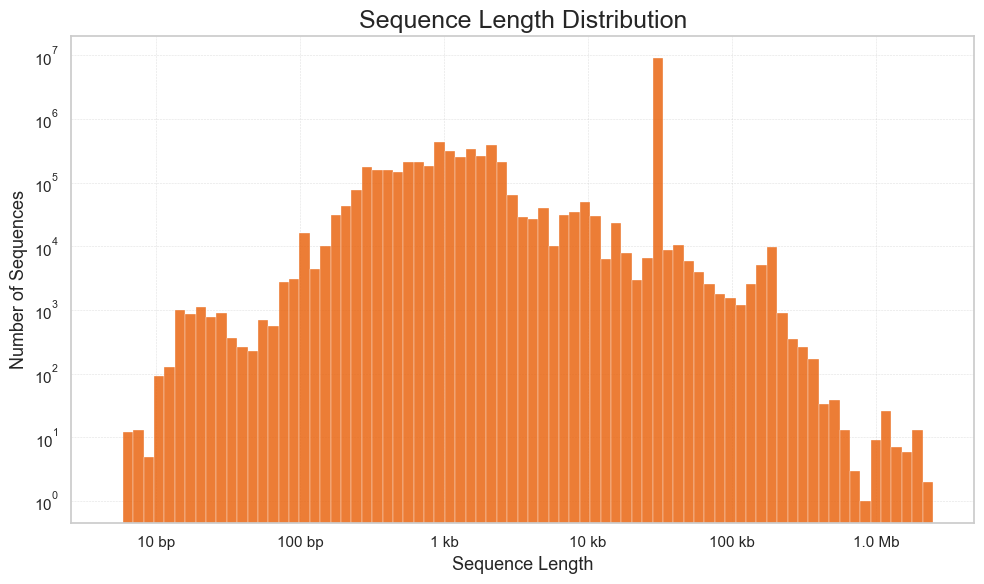

Sequence length summary:
count    1.304992e+07
mean     2.146392e+04
std      1.504128e+04
min      5.000000e+00
25%      2.275000e+03
50%      2.976900e+04
75%      2.986600e+04
max      2.473870e+06
Name: sequence_length, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

log_bins = np.logspace(
    np.log10(df_clean['sequence_length'].min()),
    np.log10(df_clean['sequence_length'].max()),
    num=80 
)

ax.hist(
    df_clean['sequence_length'],
    bins=log_bins,
    color='#E85D04',
    alpha=0.8,
    edgecolor='white',
    linewidth=0.3
)

ax.set_xscale('log')
ax.set_yscale('log')

# Readable labels in pairs instead of raw numbers like 1e+04
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{int(x):,} bp' if x < 1000 else
                 f'{int(x/1000):,} kb' if x < 1_000_000 else
                 f'{x/1_000_000:.1f} Mb'
))

ax.set_xlabel('Sequence Length', fontsize=13)
ax.set_ylabel('Number of Sequences', fontsize=13)
ax.set_title('Sequence Length Distribution', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.show()

print("Sequence length summary:")
print(df_clean['sequence_length'].describe())

### Plot for Number of Clusters by GC Content

* BAR PLOT

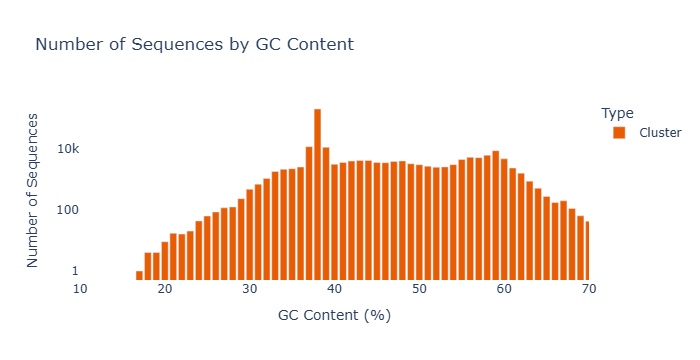

In [49]:
if 'sequence_gc_content' in df.columns and 'is_cluster' in df.columns:

    df_gc = df.dropna(subset=['sequence_gc_content', 'is_cluster'])
    df_gc = df_gc[(df_gc['sequence_gc_content'] >= 0) & (df_gc['sequence_gc_content'] <= 100)]

    # Round GC to nearest integer so x-axis shows clean numbers like 10, 11, 12...
    df_gc['gc_rounded'] = df_gc['sequence_gc_content'].round(0).astype(int)

    # Label the is_cluster column in plain English
    df_gc['type'] = df_gc['is_cluster'].map({True: 'Cluster', False: 'No_cluster'})

    # Count how many sequences fall at each GC value, split by type
    gc_grouped = df_gc.groupby(['gc_rounded', 'type']).size().reset_index(name='count')

    fig = px.bar(
        gc_grouped,
        x='gc_rounded',
        y='count',
        color='type',
        barmode='stack',
        log_y=True,
        title='Number of Sequences by GC Content',
        labels={
            'gc_rounded': 'GC Content (%)',
            'count': 'Number of Sequences',
            'type': 'Type'
        },
        color_discrete_map={'Cluster': '#E85D04', 'No_cluster': '#1D3557'}
    )

    fig.update_layout(
        xaxis=dict(
            tickmode='linear',
            tick0=10,
            dtick=10,          
            range=[10, 70]      
        ),
        plot_bgcolor='white',
        paper_bgcolor='white'
    )

    fig.show()

else:
    print("Columns 'sequence_gc_content' or 'is_cluster' not found.")


* SCATTER PLOT

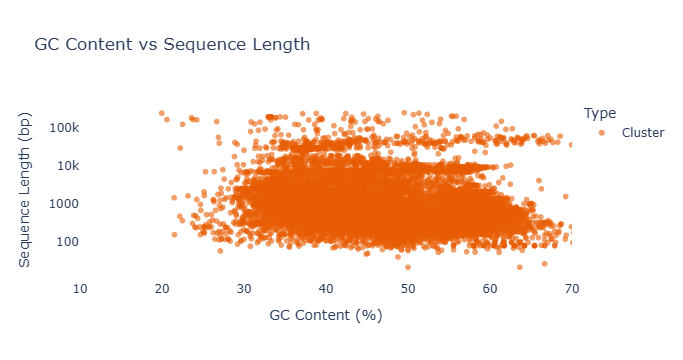

In [70]:
#Scatter plot

df_plot = df_gc.sample(n=50000, random_state=42) if len(df_gc) > 50000 else df_gc

fig = px.scatter(
    df_plot,
    x='sequence_gc_content',
    y='sequence_length',
    color='type',
    log_y=True,
    size_max=3,
    opacity=0.6,           
    title='GC Content vs Sequence Length',
    labels={
        'sequence_gc_content': 'GC Content (%)',
        'sequence_length': 'Sequence Length (bp)',
        'type': 'Type'
    },
    color_discrete_map={'Cluster': '#E85D04', 'Singleton': '#1D3157'}
)

fig.update_layout(
    xaxis=dict(range=[10, 70]),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

* SCATTER PLOT USING MATPLOTLIB

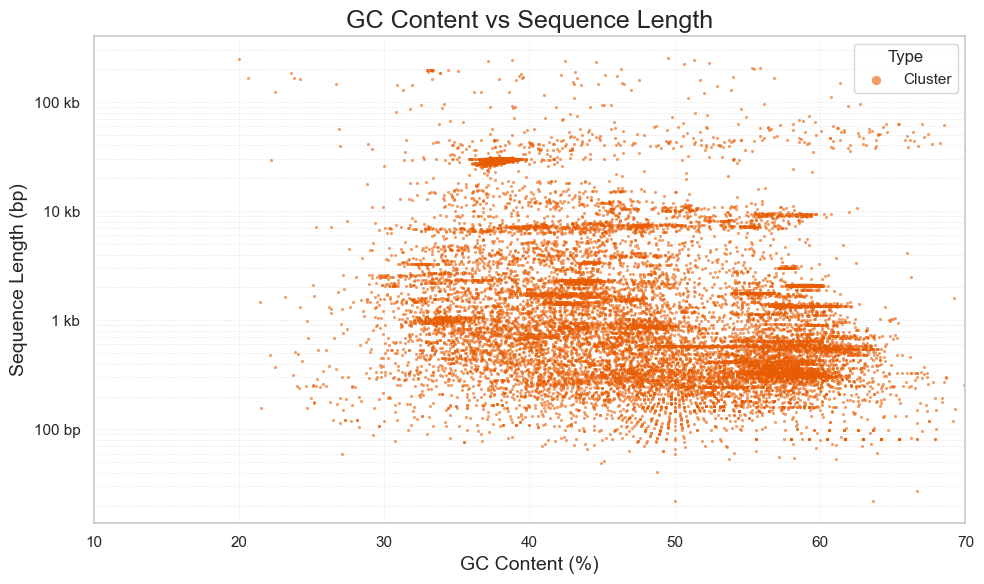

In [71]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_gc.sample(n=50000, random_state=42) if len(df_gc) > 50000 else df_gc
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Cluster': '#E85D04', 'No_cluster': '#1D3157'}

for label, group in df_plot.groupby('type'):
    ax.scatter(
        group['sequence_gc_content'],
        group['sequence_length'],
        c=colors[label],
        label=label,
        s=5,           
        alpha=0.6,     
        linewidths=0   
    )

ax.set_yscale('log')
ax.set_xlabel('GC Content (%)', fontsize=14)
ax.set_ylabel('Sequence Length (bp)', fontsize=14)
ax.set_title('GC Content vs Sequence Length', fontsize=18)
ax.set_xlim(10, 70)
ax.set_xticks([10, 20, 30, 40, 50, 60, 70])

# Y axis readable labels ( labelled in pairs)
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{int(x):,} bp' if x < 1000 else
                 f'{int(x/1000):,} kb' if x < 1_000_000 else
                 f'{x/1_000_000:.1f} Mb'
))

ax.legend(title='Type', markerscale=3, fontsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

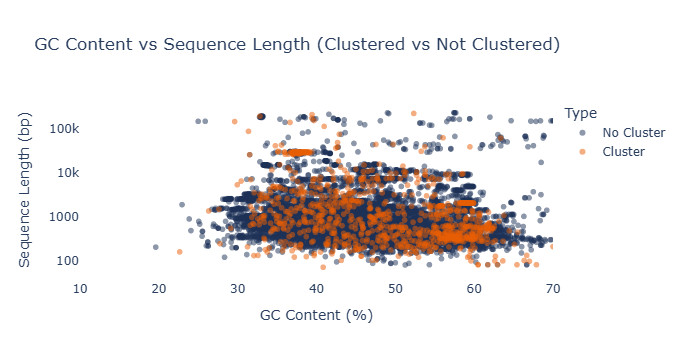

Type counts:
type
No Cluster    11013263
Cluster         315335
Name: count, dtype: int64


In [72]:

# Only drop rows missing GC content or sequence length.  NaN would be assigned to 'is_cluster'
df_gc2 = df.dropna(subset=['sequence_gc_content', 'sequence_length'])
df_gc2 = df_gc2[(df_gc2['sequence_gc_content'] >= 0) & (df_gc2['sequence_gc_content'] <= 100)]


df_gc2['type'] = df_gc2['is_cluster'].map({True: 'Cluster'}).fillna('No Cluster')

# Sample down cos million points could cause a crash 
df_plot = df_gc2.sample(n=100000, random_state=42) if len(df_gc2) > 100000 else df_gc2

fig = px.scatter(
    df_plot,
    x='sequence_gc_content',
    y='sequence_length',
    color='type',
    log_y=True,
    opacity=0.5,
    title='GC Content vs Sequence Length (Clustered vs Not Clustered)',
    labels={
        'sequence_gc_content': 'GC Content (%)',
        'sequence_length': 'Sequence Length (bp)',
        'type': 'Type'
    },
    color_discrete_map={
        'Cluster': '#E85D04',
        'No Cluster': '#1D3157'
    }
)

fig.update_layout(
    xaxis=dict(
        range=[10, 70],
        tickvals=[10, 20, 30, 40, 50, 60, 70]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
print("Type counts:")
print(df_gc2['type'].value_counts())

In [65]:
# How many True rows have missing GC content?
true_rows = df[df['is_cluster'] == True]
print(f"Total True rows in df: {len(true_rows)}")

# Missing GC
missing_gc = true_rows['sequence_gc_content'].isna().sum()
print(f"True rows with missing GC: {missing_gc}")

# GC out of range (0 - 100)
out_of_range = true_rows[
    (true_rows['sequence_gc_content'] < 0) | 
    (true_rows['sequence_gc_content'] > 100)
].shape[0]
print(f"True rows with GC out of 0-100 range: {out_of_range}")


Total True rows in df: 647827
True rows with missing GC: 332492
True rows with GC out of 0-100 range: 0


In [64]:
# What percentage of clustered sequences are missing GC?
pct_missing = (332492 / 647827) * 100
print(f"Clustered sequences missing GC content: {pct_missing:.1f}%")

# Are they all missing GC sequences partial? All from the same country? All the same molecule type?
true_missing_gc = df[(df['is_cluster'] == True) & (df['sequence_gc_content'].isna())]

print("\nSequence completeness breakdown for missing GC rows:")
print(true_missing_gc['sequence_completeness'].value_counts())

print("\nMolecule type breakdown:")
print(true_missing_gc['molecule_type'].value_counts())

print("\nTop 5 submitter countries:")
print(true_missing_gc['submitter_country'].value_counts().head())

Clustered sequences missing GC content: 51.3%

Sequence completeness breakdown for missing GC rows:
sequence_completeness
partial     304480
complete     28012
Name: count, dtype: int64

Molecule type breakdown:
molecule_type
ssRNA-RT        226332
dsDNA            37511
ssRNA(+)         25492
unknown          10561
ssDNA(-)          8197
dsRNA             7188
RNA               6032
ssDNA(+/-)        3783
ssDNA             3441
ssRNA(-)          1831
dsDNA-RT           830
ssRNA              593
ssDNA(+)           562
DNA                131
dsDNA; ssDNA         6
ssRNA(+/-)           2
Name: count, dtype: int64

Top 5 submitter countries:
submitter_country
USA             105675
China            24171
Brazil           17515
France           13602
South Africa     12613
Name: count, dtype: int64


**51.3% of clustered sequences have no GC content recorded and most missing GC sequences are RNA viruses (ssRNA-RT: 226,332 rows). This signifies that RNA virus GC content is often not reported in NCBI submissions. Also, partial sequences account for most of the GC content (304,480 rows)**

In [63]:
# Run this to see the complete breakdown clearly
total = len(df)
clustered = df['is_cluster'].sum()
not_clustered = df['is_cluster'].isna().sum()

print(f"Total sequences in dataset:        {total:>15,}")
print(f"Clustered (is_cluster = True):     {clustered:>15,}")
print(f"Not clustered (is_cluster = NaN):  {not_clustered:>15,}")
print(f"Clustered %:                       {clustered/total*100:>14.1f}%")
print(f"Not clustered %:                   {not_clustered/total*100:>14.1f}%")

Total sequences in dataset:             13,049,920
Clustered (is_cluster = True):             647,827
Not clustered (is_cluster = NaN):       12,402,093
Clustered %:                                  5.0%
Not clustered %:                             95.0%


**Approximately 95% of sequences in this database have never been clustered which could mean that majority of viral diversity in this dataset is novel and unique.**

### Plot: Log Scale on Existing Bar Plots

**Top 10 submitter countries with a log x-axis.**

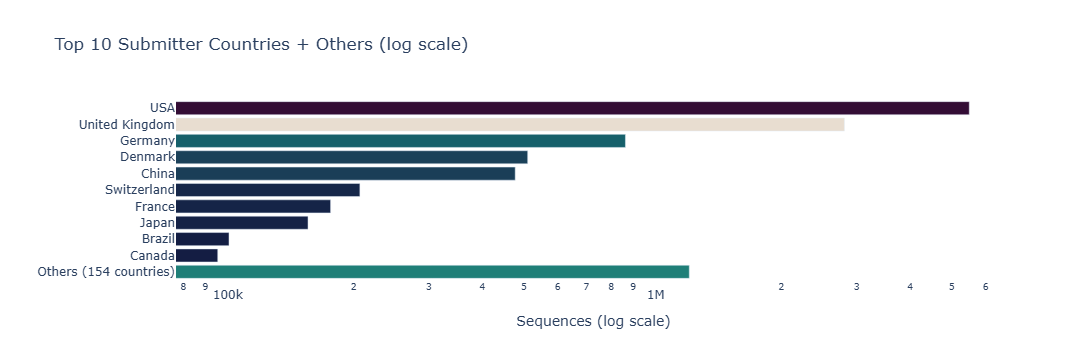

In [139]:
# Top 10 submitter countries with Others fixed at the bottom
if 'submitter_country' in df.columns:

    all_countries = (
        df['submitter_country']
        .value_counts()
        .reset_index()
    )
    all_countries.columns = ['country', 'count']

    top10 = all_countries.head(10)
    others_count = all_countries.iloc[10:]['count'].sum()
    others_n = len(all_countries) - 10

    others_row = pd.DataFrame([{'country': f'Others ({others_n} countries)', 'count': others_count}])
    top_countries = pd.concat([top10, others_row], ignore_index=True)

    # Sort top 10 ascending but keep Others at the bottom
    top10_sorted = top_countries[~top_countries['country'].str.startswith('Others')].sort_values('count', ascending=True)
    others_only = top_countries[top_countries['country'].str.startswith('Others')]
    top_countries_final = pd.concat([others_only, top10_sorted], ignore_index=True)

    # Fix the y-axis order exactly as the dataframe is arranged
    country_order = top_countries_final['country'].tolist()

    fig = px.bar(
        top_countries_final,
        x='count',
        y='country',
        orientation='h',
        log_x=True,
        title='Top 10 Submitter Countries + Others (log scale)',
        labels={'count': 'Sequences (log scale)', 'country': ''},
        color='count',
        color_continuous_scale='curl'
    )

    fig.update_layout(
        yaxis=dict(categoryorder='array', categoryarray=country_order),
        plot_bgcolor='white',
        paper_bgcolor='white',
        coloraxis_showscale=False
    )

    fig.show()

**Sequence Completeness Plot**

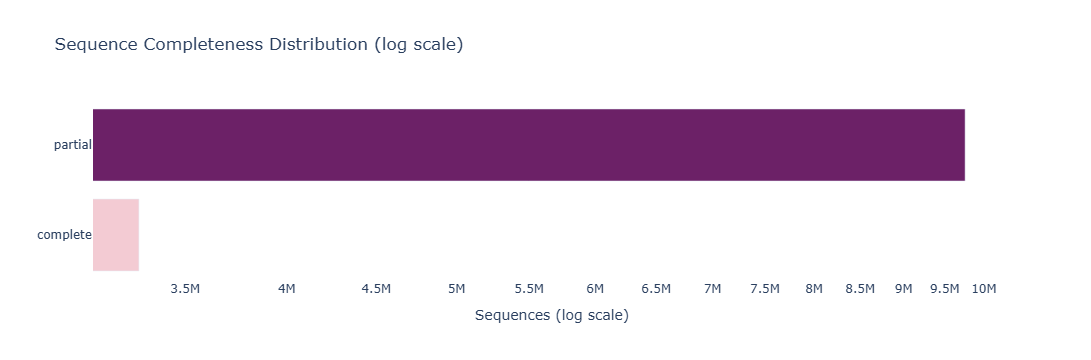

In [138]:
if 'sequence_completeness' in df.columns:

    completeness_counts = (
        df['sequence_completeness']
        .value_counts()
        .reset_index()
    )
    completeness_counts.columns = ['completeness', 'count']

    fig = px.bar(
        completeness_counts,
        x='count',
        y='completeness',
        orientation='h',
        log_x=True,
        title='Sequence Completeness Distribution (log scale)',
        labels={'count': 'Sequences (log scale)', 'completeness': ''},
        color='count',
        color_continuous_scale='magenta'
    )

    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        plot_bgcolor='white',
        paper_bgcolor='white',
        coloraxis_showscale=False
    )

    fig.show()

**Sequence Length Distribution**

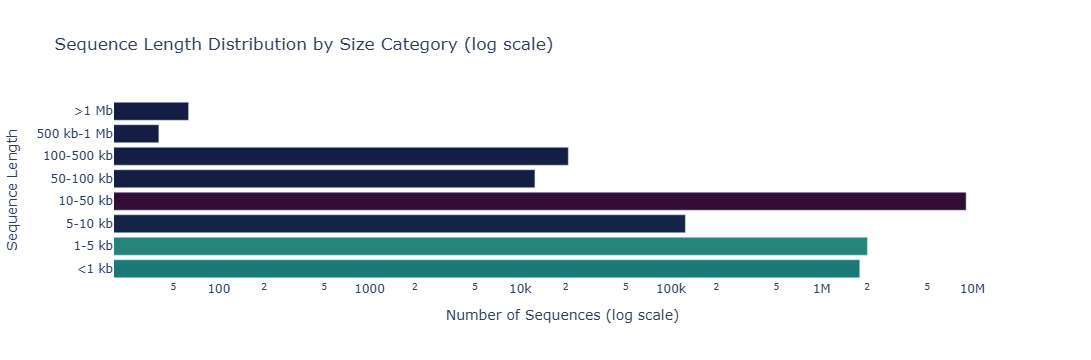

In [137]:
if 'sequence_length' in df.columns:

    df_len = df.dropna(subset=['sequence_length'])
    df_len = df_len[df_len['sequence_length'] > 0]

    bins = [0, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, float('inf')]
    labels = [
        '<1 kb',
        '1-5 kb',
        '5-10 kb',
        '10-50 kb',
        '50-100 kb',
        '100-500 kb',
        '500 kb-1 Mb',
        '>1 Mb'
    ]

    df_len['length_bin'] = pd.cut(df_len['sequence_length'], bins=bins, labels=labels)

    length_counts = (
        df_len['length_bin']
        .value_counts()
        .reset_index()
    )
    length_counts.columns = ['length_range', 'count']

    # Keep biological size order (small to large) — bottom to top on horizontal bar
    length_counts['length_range'] = pd.Categorical(
        length_counts['length_range'], categories=labels, ordered=True
    )
    length_counts = length_counts.sort_values('length_range', ascending=True)

    fig = px.bar(
        length_counts,
        x='count',           
        y='length_range',    
        orientation='h',     
        log_x=True,          
        title='Sequence Length Distribution by Size Category (log scale)',
        labels={
            'count': 'Number of Sequences (log scale)',
            'length_range': 'Sequence Length'
        },
        color='count',
        color_continuous_scale='curl'
    )

    fig.update_layout(
        # Fix y axis order so <1kb is at bottom and >1Mb is at top
        yaxis=dict(categoryorder='array', categoryarray=labels),
        plot_bgcolor='white',
        paper_bgcolor='white',
        coloraxis_showscale=False
    )

    fig.show()

### Plot: World Map of Submission Countries

In [116]:
# Step 1: Count sequences per country

if 'submitter_country' in df.columns:

    country_counts = (
        df['submitter_country']
        .value_counts()
        .reset_index()
    )
    country_counts.columns = ['country_name', 'count']

    print("Top 10 submitting countries:")
    print(country_counts.head(10))
else:
    print("No 'submitter_country' column found.")

Top 10 submitting countries:
     country_name    count
0             USA  5497357
1  United Kingdom  2807681
2         Germany   863844
3         Denmark   510447
4           China   477251
5     Switzerland   206848
6          France   176682
7           Japan   156465
8          Brazil   102263
9          Canada    96247


In [121]:
# Step 2: Convert country names to ISO-3 codes 
# Plotly choropleth maps need 3-letter ISO codes (e.g. 'USA', 'DEU', 'CHN').
# pycountry does this conversion. Some country names in NCBI don't match perfectly, so we handle mismatches manually in a lookup dictionary.

import pycountry

manual_fixes = {
    'Usa': 'USA',
    'United States': 'USA',
    'United States Of America': 'USA',
    'Uk': 'GBR',
    'United Kingdom': 'GBR',
    'South Korea': 'KOR',
    'Republic Of Korea': 'KOR',
    'Russia': 'RUS',
    'Czech Republic': 'CZE',
    'Iran': 'IRN',
    'Taiwan': 'TWN',
    'Venezuela': 'VEN',
    'Bolivia': 'BOL',
    'Germany': 'DEU',
    'Denmark': 'DNK',
    'China': 'CHN',
    'Switzerland': 'CHE',
    'France': 'FRA',
    'Japan': 'JPN',
    'Brazil': 'BRA',
    'Canada': 'CAN',
    'Australia': 'AUS',
    'India': 'IND',
    'South Africa': 'ZAF',
    'Italy': 'ITA',
    'Spain': 'ESP',
    'Thailand': 'THA',
    'Slovakia': 'SVK',
    'Netherlands': 'NLD',
    'Belgium': 'BEL',
    'Kenya': 'KEN',
    'Argentina': 'ARG',
    'Mexico': 'MEX',
    'Sweden': 'SWE',
    'Iceland': 'ISL',
    'New Zealand': 'NZL',
    'Singapore': 'SGP',
    'Poland': 'POL',
    'Turkey': 'TUR',
    'Korea': 'KOR',
    'Pakistan': 'PAK',
    'Bahrain': 'BHR',
    'Hong Kong': 'HKG',
    'Ireland': 'IRL',
    'Egypt': 'EGY',
    'Portugal': 'PRT',
    'Malaysia': 'MYS',
    'Uganda': 'UGA',
    'Cameroon': 'CMR',
    'Finland': 'FIN',
    'Hungary': 'HUN',
    'Viet Nam': 'VNM',
    'Israel': 'ISR',
    'Cambodia': 'KHM',
    'Indonesia': 'IDN',
    'Nigeria': 'NGA',
    'Greece': 'GRC',
    'Croatia': 'HRV',
    'Slovenia': 'SVN',
    'Colombia': 'COL',
    'Bangladesh': 'BGD',
    'Norway': 'NOR',
    'Austria': 'AUT',
    'Saudi Arabia': 'SAU',
    'Luxembourg': 'LUX',
    'Tunisia': 'TUN',
    'Philippines': 'PHL',
    'Tanzania': 'TZA',
    'Peru': 'PER',
    'Estonia': 'EST',
    'Serbia': 'SRB',
    'Cuba': 'CUB',
    'Chile': 'CHL',
    'Romania': 'ROU',
    'Uruguay': 'URY',
    'Iraq': 'IRQ',
    'Mozambique': 'MOZ',
    'Gabon': 'GAB',
    'Morocco': 'MAR',
    'Belarus': 'BLR',
    'Ethiopia': 'ETH',
    'Laos': 'LAO',
    'Cyprus': 'CYP',
    'Senegal': 'SEN',
    'Bulgaria': 'BGR',
    'Malawi': 'MWI',
    'Madagascar': 'MDG',
    'Kazakhstan': 'KAZ',
    'Benin': 'BEN',
    'Botswana': 'BWA',
    'Ghana': 'GHA',
    'Reunion': 'REU',
    'Zambia': 'ZMB',
    'Lebanon': 'LBN',
    'Ecuador': 'ECU',
    'Zimbabwe': 'ZWE',
    'Kuwait': 'KWT',
    'Panama': 'PAN',
    'Costa Rica': 'CRI',
    'Martinique': 'MTQ',
    'Democratic Republic Of The Congo': 'COD',
    'Democratic Republic of the Congo': 'COD',
    'Ukraine': 'UKR',
    'Uzbekistan': 'UZB',
    'Oman': 'OMN',
    'Mongolia': 'MNG',
    'Nepal': 'NPL',
    'Lithuania': 'LTU',
    'Gambia': 'GMB',
    'Central African Republic': 'CAF',
    'Georgia': 'GEO',
    'Myanmar': 'MMR',
    'Saint Kitts And Nevis': 'KNA',
    'Saint Kitts and Nevis': 'KNA',
    'Honduras': 'HND',
    'Jordan': 'JOR',
    'Papua New Guinea': 'PNG',
    'Algeria': 'DZA',
    'Burkina Faso': 'BFA',
    'Bosnia And Herzegovina': 'BIH',
    'Bosnia and Herzegovina': 'BIH',
    'Jamaica': 'JAM',
    'Paraguay': 'PRY',
    'Faroe Islands': 'FRO',
    'Sri Lanka': 'LKA',
    'Latvia': 'LVA',
    'Trinidad And Tobago': 'TTO',
    'Trinidad and Tobago': 'TTO',
    'French Polynesia': 'PYF',
    'Togo': 'TGO',
    'Sudan': 'SDN',
    'Nicaragua': 'NIC',
    'Syria': 'SYR',
    'Mali': 'MLI',
    'United Arab Emirates': 'ARE',
    'Macedonia': 'MKD',
    'Guatemala': 'GTM',
    'Montenegro': 'MNE',
    'New Caledonia': 'NCL',
    'Guadeloupe': 'GLP',
    'Qatar': 'QAT',
    'French Guiana': 'GUF',
    'State Of Palestine': 'PSE',
    'State of Palestine': 'PSE',
    "Cote D'Ivoire": 'CIV',
    'Cote Divoire': 'CIV',
    'Angola': 'AGO',
    'Bhutan': 'BTN',
    'Libya': 'LBY',
    'Barbados': 'BRB',
    'Burundi': 'BDI',
    'Namibia': 'NAM',
    'Rwanda': 'RWA',
    'Yugoslavia': 'YUG',       
    'Sierra Leone': 'SLE',
    'Guinea': 'GIN',
    'Mauritius': 'MUS',
    'Swaziland': 'SWZ',
    'Republic Of The Congo': 'COG',
    'Republic of the Congo': 'COG',
    'Suriname': 'SUR',
    'Afghanistan': 'AFG',
    'Malta': 'MLT',
    'Eritrea': 'ERI',
    'Serbia And Montenegro': 'SCG',  
    'Grenada': 'GRD',
    'Armenia': 'ARM',
    'Azerbaijan': 'AZE',
    'Yemen': 'YEM',
    'Dominican Republic': 'DOM',
    'Albania': 'ALB',
    'Fiji': 'FJI',
    'West Bank': 'PSE',
    'Ussr': 'RUS',              
    'USSR': 'RUS',
    'Tajikistan': 'TJK',
}

def name_to_iso3(name):
    if not isinstance(name, str):
        return None
    name_clean = name.strip().title()

    # Check manual fixes first — fastest and most reliable
    if name_clean in manual_fixes:
        return manual_fixes[name_clean]

    # Also check original casing in case .title() broke something
    if name.strip() in manual_fixes:
        return manual_fixes[name.strip()]

    # Last resort — pycountry exact match
    try:
        match = pycountry.countries.search_fuzzy(name_clean)
        return match[0].alpha_3
    except Exception:
        return None

country_counts['iso3'] = country_counts['country_name'].apply(name_to_iso3)

# Check how many are still unmatched
unmatched = country_counts[country_counts['iso3'].isna()]
print(f"Still unmatched: {len(unmatched)}")
print(unmatched['country_name'].tolist())

Still unmatched: 0
[]


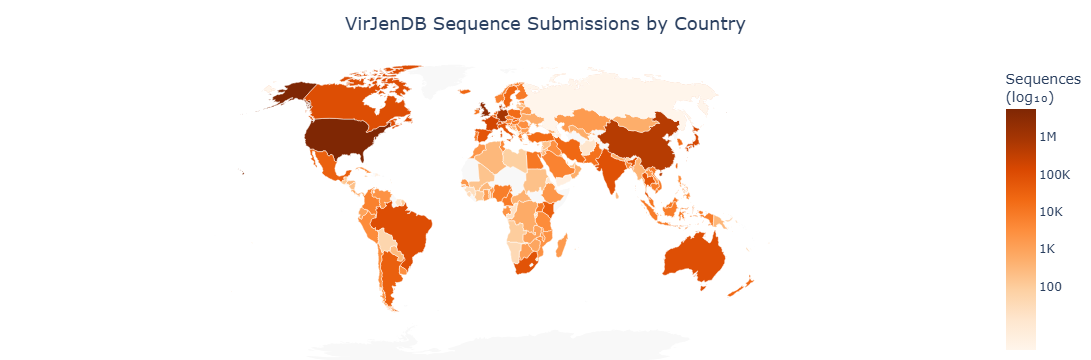

In [143]:
# Step 3:  build the map

import plotly.graph_objects as go
import numpy as np

# Step 1: Count and prepare data 
if 'submitter_country' in df.columns:

    country_counts = (
        df['submitter_country']
        .value_counts()
        .reset_index()
    )
    country_counts.columns = ['country_name', 'count']

    # Convert to ISO-3
    country_counts['iso3'] = country_counts['country_name'].apply(name_to_iso3)
    map_df = country_counts.dropna(subset=['iso3']).copy()

    # Log scale the count for better color distribution
    map_df['log_count'] = np.log10(map_df['count'] + 1)

    # Step 2: Build map using go.Choropleth 
    fig_map = go.Figure(data=go.Choropleth(
        locations=map_df['iso3'],
        z=map_df['log_count'],               
        text=map_df['country_name'],          
        customdata=map_df['count'],           
        colorscale='Oranges',
        autocolorscale=False,
        reversescale=False,                   
        marker_line_color='white',            
        marker_line_width=0.5,
        colorbar=dict(
            title='Sequences<br>(log₁₀)',
            tickvals=[2, 3, 4, 5, 6],
            ticktext=['100', '1K', '10K', '100K', '1M']
        ),
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Sequences: %{customdata:,}<br>'
            '<extra></extra>'             # removes the default trace label
        )
    ))

    fig_map.update_layout(
        title=dict(
            text='VirJenDB Sequence Submissions by Country',
            x=0.5,                            
            font=dict(size=18)
        ),
        geo=dict(
            showframe=False,
            showcoastlines=False,
            coastlinecolor='lightgrey',
            showland=True,
            landcolor='#f8f8f8',              
            showocean=False,
            oceancolor='#e8f4f8',
            showlakes=False,
            projection_type='natural earth'
        ),
        paper_bgcolor='white',
        margin=dict(l=0, r=0, t=60, b=0)
    )

    fig_map.show()



In [144]:
fig_map.write_html('virjendb_world_map.html')
print("Map saved to virjendb_world_map.html")

Map saved to virjendb_world_map.html


In [145]:
# Check where the file is actually being saved
import os
print(f"Saving to: {os.getcwd()}")  # this shows you the exact folder

fig_map.write_html(
    'virjendb_world_map.html',
    include_plotlyjs='cdn',    # loads plotly from internet — keeps file small
    full_html=True             # makes it a complete standalone html file
)

print(f"Map saved to: {os.path.join(os.getcwd(), 'virjendb_world_map.html')}")

Saving to: C:\Users\hp\Jen - VizAvalanche
Map saved to: C:\Users\hp\Jen - VizAvalanche\virjendb_world_map.html


In [146]:
import os

filepath = os.path.join(os.getcwd(), 'virjendb_world_map.html')
print(f"Open this file in your browser:")
print(filepath)

Open this file in your browser:
C:\Users\hp\Jen - VizAvalanche\virjendb_world_map.html
